In [1]:
import json
import os

with open("data/entities/combined_entities.json",
          encoding="utf-8") as f:
    entities = json.load(f)

with open("data/cleaned_text/all_cleaned.json",
          encoding="utf-8") as f:
    cleaned_docs = json.load(f)

print("✓ Data loaded")
for doc, data in entities.items():
    print(f"  {doc}: {data['total']} entities")

✓ Data loaded
  arabic_doc_001.jpg: 9 entities
  arabic_doc_004.jpg: 11 entities
  arabic_doc_005.jpg: 16 entities


In [2]:
import subprocess
subprocess.run(["pip3", "install", "networkx", "matplotlib"],
               capture_output=True)

import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

print("✓ NetworkX ready")
print(f"  Version: {nx.__version__}")

✓ NetworkX ready
  Version: 3.2.1


In [3]:
# Create directed graph
G = nx.DiGraph()

# Color scheme for different entity types
type_colors = {
    "DOCUMENT": "#2C3E50",
    "PERSON": "#E74C3C",
    "PERS": "#E74C3C",
    "LOCATION": "#3498DB",
    "LOC": "#3498DB",
    "PLACE": "#3498DB",
    "ORGANIZATION": "#2ECC71",
    "ORG": "#2ECC71",
    "MISC": "#F39C12",
    "DATE": "#9B59B6"
}

# Normalize entity type names
def normalize_type(etype):
    mapping = {
        "PERS": "PERSON",
        "LOC": "LOCATION",
        "ORG": "ORGANIZATION",
        "PLACE": "LOCATION",
        "MISC": "MISC"
    }
    return mapping.get(etype, etype)

# Add document nodes
for doc_name in entities.keys():
    short_name = doc_name.replace('arabic_doc_', 'Doc_').replace('.jpg', '')
    G.add_node(short_name,
               node_type="DOCUMENT",
               color="#2C3E50",
               size=3000,
               label=short_name)

# Add entity nodes and edges
for doc_name, doc_data in entities.items():
    short_name = doc_name.replace('arabic_doc_', 'Doc_').replace('.jpg', '')
    
    for etype, elist in doc_data['entities'].items():
        norm_type = normalize_type(etype)
        color = type_colors.get(norm_type, "#95A5A6")
        
        for entity in elist:
            # Clean entity text
            clean_entity = entity.strip()
            if len(clean_entity) < 2:
                continue
            
            # Add entity node if not exists
            if clean_entity not in G.nodes():
                G.add_node(clean_entity,
                          node_type=norm_type,
                          color=color,
                          size=1500,
                          label=clean_entity)
            
            # Add edge from document to entity
            G.add_edge(short_name, clean_entity,
                      relation=f"contains_{norm_type.lower()}")

print(f"✓ Graph built!")
print(f"  Nodes: {G.number_of_nodes()}")
print(f"  Edges: {G.number_of_edges()}")
print(f"\nNode types:")
type_counts = {}
for node, data in G.nodes(data=True):
    ntype = data.get('node_type', 'UNKNOWN')
    type_counts[ntype] = type_counts.get(ntype, 0) + 1
for ntype, count in sorted(type_counts.items()):
    print(f"  {ntype}: {count}")

✓ Graph built!
  Nodes: 39
  Edges: 36

Node types:
  DOCUMENT: 3
  LOCATION: 14
  MISC: 1
  ORGANIZATION: 11
  PERSON: 10


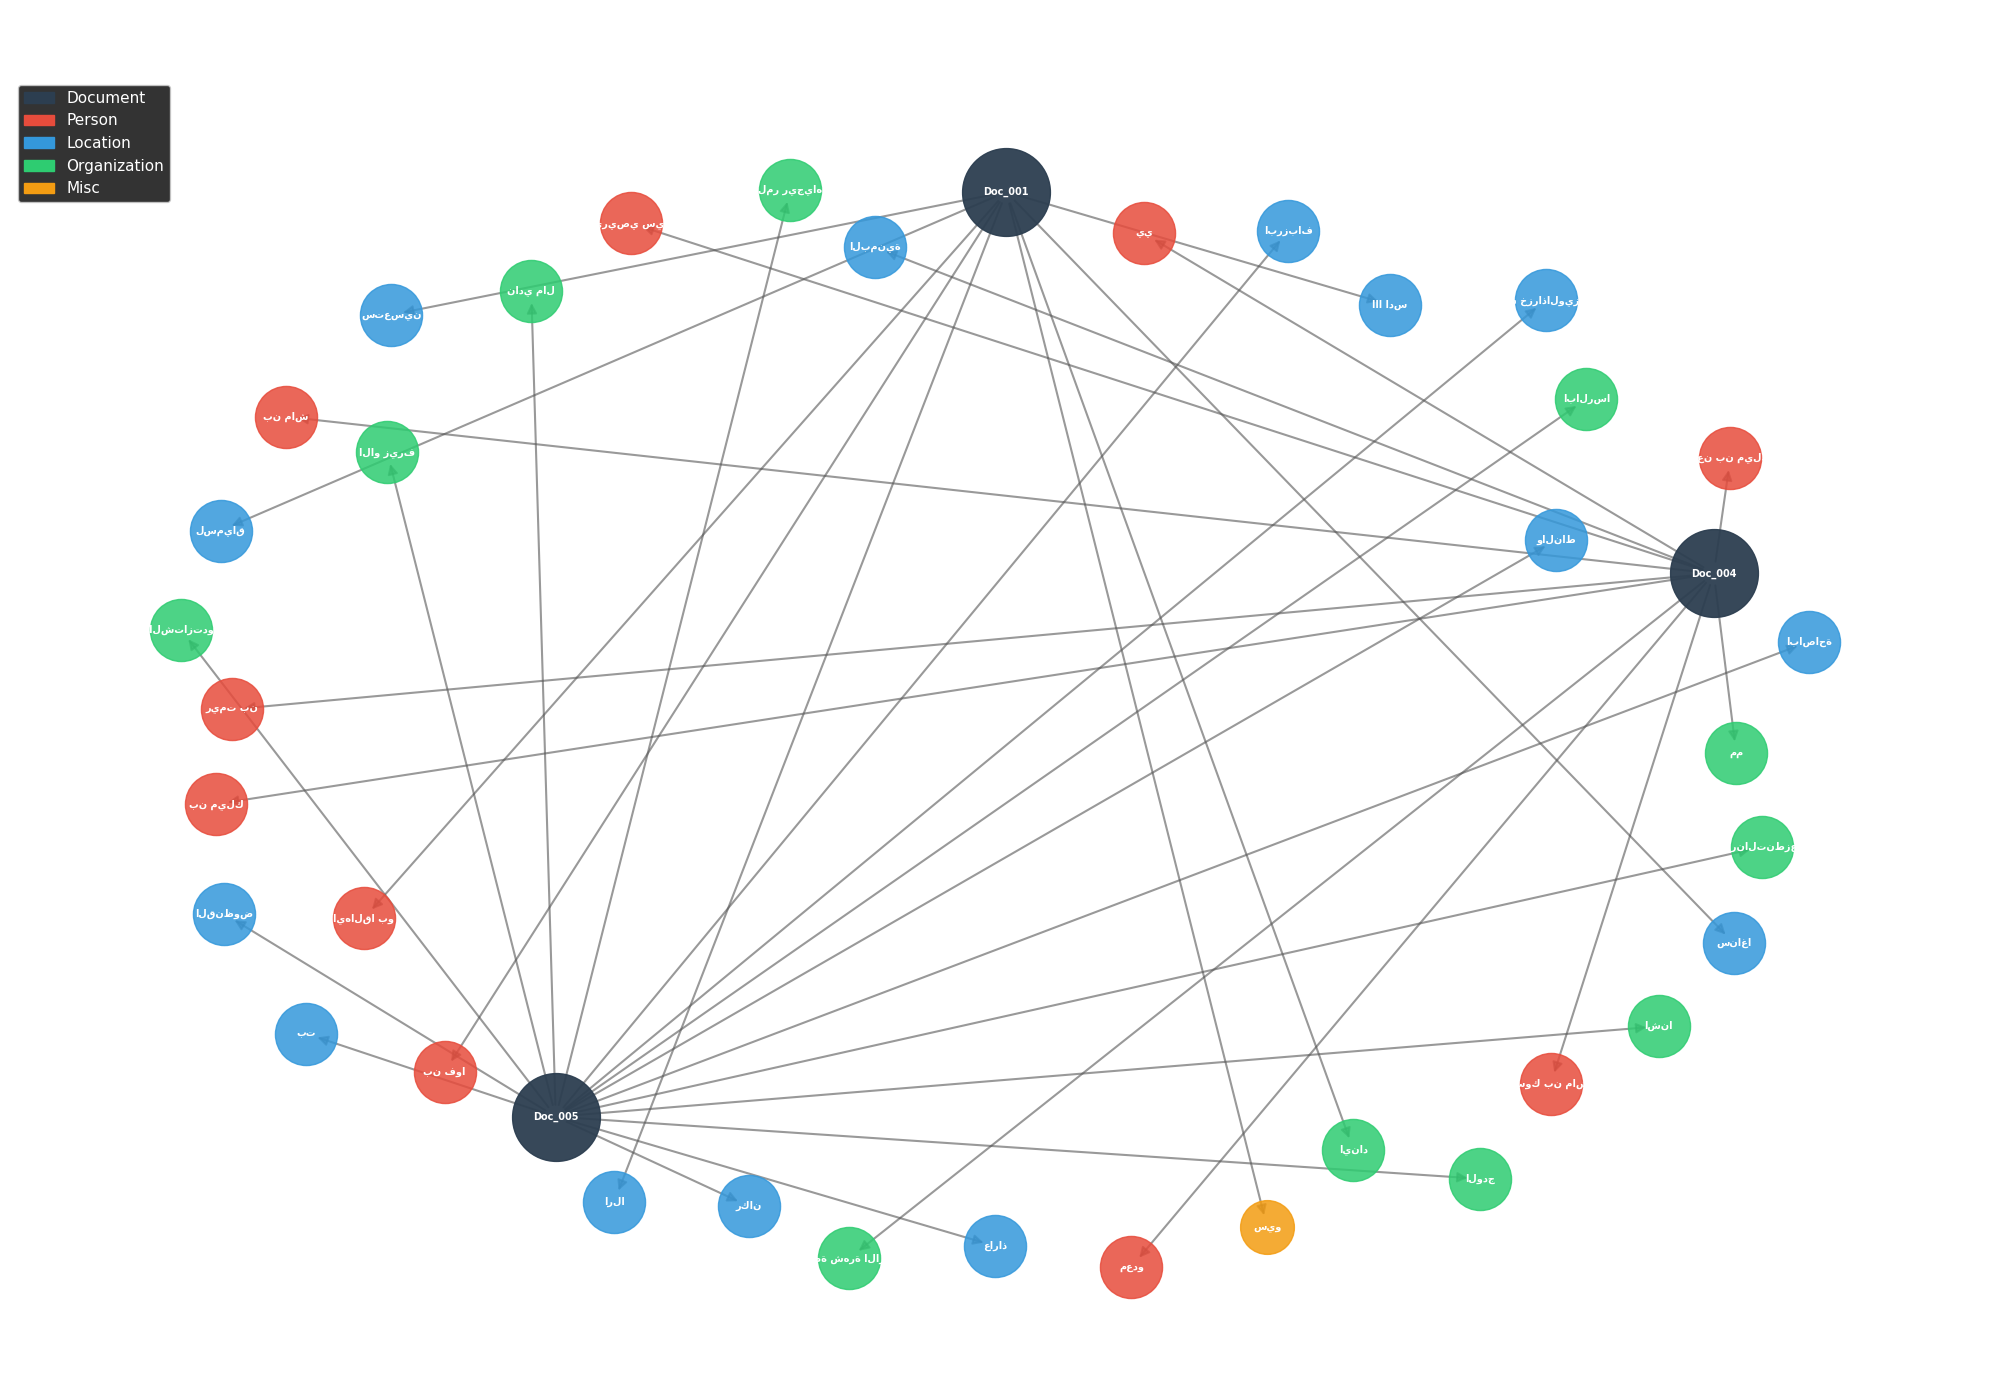

✓ Knowledge graph saved!


In [4]:
plt.figure(figsize=(20, 14))
plt.style.use('dark_background')

# Layout
pos = nx.spring_layout(G, k=3, iterations=50, seed=42)

# Separate nodes by type
doc_nodes = [n for n, d in G.nodes(data=True) 
             if d.get('node_type') == 'DOCUMENT']
person_nodes = [n for n, d in G.nodes(data=True) 
                if d.get('node_type') == 'PERSON']
location_nodes = [n for n, d in G.nodes(data=True) 
                  if d.get('node_type') == 'LOCATION']
org_nodes = [n for n, d in G.nodes(data=True) 
             if d.get('node_type') == 'ORGANIZATION']
other_nodes = [n for n, d in G.nodes(data=True) 
               if d.get('node_type') not in 
               ['DOCUMENT','PERSON','LOCATION','ORGANIZATION']]

# Draw each node type
nx.draw_networkx_nodes(G, pos, nodelist=doc_nodes,
    node_color='#2C3E50', node_size=4000, alpha=0.95)
nx.draw_networkx_nodes(G, pos, nodelist=person_nodes,
    node_color='#E74C3C', node_size=2000, alpha=0.85)
nx.draw_networkx_nodes(G, pos, nodelist=location_nodes,
    node_color='#3498DB', node_size=2000, alpha=0.85)
nx.draw_networkx_nodes(G, pos, nodelist=org_nodes,
    node_color='#2ECC71', node_size=2000, alpha=0.85)
nx.draw_networkx_nodes(G, pos, nodelist=other_nodes,
    node_color='#F39C12', node_size=1500, alpha=0.85)

# Draw edges
nx.draw_networkx_edges(G, pos,
    edge_color='#555555', arrows=True,
    arrowsize=15, width=1.5, alpha=0.6)

# Draw labels
nx.draw_networkx_labels(G, pos,
    font_size=7, font_color='white',
    font_weight='bold')

# Legend
legend_elements = [
    mpatches.Patch(color='#2C3E50', label='Document'),
    mpatches.Patch(color='#E74C3C', label='Person'),
    mpatches.Patch(color='#3498DB', label='Location'),
    mpatches.Patch(color='#2ECC71', label='Organization'),
    mpatches.Patch(color='#F39C12', label='Misc'),
]
plt.legend(handles=legend_elements, loc='upper left',
           fontsize=11, framealpha=0.8)

plt.title('Knowledge Graph: Arabic Historical Documents\nEntities and Relationships',
          fontsize=16, fontweight='bold', color='white', pad=20)
plt.axis('off')
plt.tight_layout()

os.makedirs("data/knowledge_graph", exist_ok=True)
plt.savefig("data/knowledge_graph/entity_graph.png",
            dpi=150, bbox_inches='tight',
            facecolor='#1a1a2e')
plt.show()
print("✓ Knowledge graph saved!")

In [5]:
print("KNOWLEDGE GRAPH ANALYSIS")
print("="*50)
print(f"Total nodes: {G.number_of_nodes()}")
print(f"Total edges: {G.number_of_edges()}")

# Most connected entities
print("\nMost connected entities:")
degree_sorted = sorted(G.degree(), 
                       key=lambda x: x[1], 
                       reverse=True)
for node, degree in degree_sorted[:10]:
    node_type = G.nodes[node].get('node_type', 'UNKNOWN')
    print(f"  {node} ({node_type}): {degree} connections")

# Save graph as JSON for web interface
graph_data = {
    "nodes": [
        {
            "id": node,
            "type": data.get('node_type', 'UNKNOWN'),
            "connections": G.degree(node)
        }
        for node, data in G.nodes(data=True)
    ],
    "edges": [
        {
            "source": u,
            "target": v,
            "relation": data.get('relation', '')
        }
        for u, v, data in G.edges(data=True)
    ]
}

with open("data/knowledge_graph/graph_data.json", "w",
          encoding="utf-8") as f:
    json.dump(graph_data, f, ensure_ascii=False, indent=2)

print("\n✓ Graph data saved for web interface!")
print(f"✓ Nodes saved: {len(graph_data['nodes'])}")
print(f"✓ Edges saved: {len(graph_data['edges'])}")

KNOWLEDGE GRAPH ANALYSIS
Total nodes: 39
Total edges: 36

Most connected entities:
  Doc_005 (DOCUMENT): 16 connections
  Doc_004 (DOCUMENT): 11 connections
  Doc_001 (DOCUMENT): 9 connections
  لسمياق (LOCATION): 1 connections
  ااا ادس (LOCATION): 1 connections
  ستعسين (LOCATION): 1 connections
  سناغا (LOCATION): 1 connections
  ارلا (LOCATION): 1 connections
  ايهالقا بو (PERSON): 1 connections
  ايناد (ORGANIZATION): 1 connections

✓ Graph data saved for web interface!
✓ Nodes saved: 39
✓ Edges saved: 36
